# EDA — TMDB 5000 Dataset

Exploratory Data Analysis before building the preprocessing pipeline.
Goal: understand column structure, missing values, JSON-encoded columns, and the join key.

In [ ]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW_DIR = Path("../raw")
MOVIES_CSV = RAW_DIR / "tmdb_5000_movies.csv"
CREDITS_CSV = RAW_DIR / "tmdb_5000_credits.csv"

print("Files exist:", MOVIES_CSV.exists(), CREDITS_CSV.exists())

## 1. Load & basic shape

In [ ]:
movies = pd.read_csv(MOVIES_CSV)
credits = pd.read_csv(CREDITS_CSV)

print("movies shape:", movies.shape)
print("credits shape:", credits.shape)

In [ ]:
print("=== movies columns ===")
display(movies.dtypes.to_frame("dtype"))
print("\n=== credits columns ===")
display(credits.dtypes.to_frame("dtype"))

## 2. Missing values

In [ ]:
key_cols = ["title", "overview", "genres", "release_date", "vote_average"]
display(movies[key_cols].isnull().sum().to_frame("nulls"))

In [ ]:
display(credits.isnull().sum().to_frame("nulls"))

## 3. Join key check

In [ ]:
print("movies.id dtype:", movies["id"].dtype)
print("credits.movie_id dtype:", credits["movie_id"].dtype)

ids_movies = set(movies["id"])
ids_credits = set(credits["movie_id"])

print("movies only:", len(ids_movies - ids_credits))
print("credits only:", len(ids_credits - ids_movies))
print("common:", len(ids_movies & ids_credits))

## 4. JSON-encoded columns

`genres`, `keywords`, `cast`, `crew` are stored as JSON strings — require `ast.literal_eval` to parse.

In [ ]:
print("genres sample:", movies["genres"].iloc[0])
print("keywords sample:", movies["keywords"].iloc[0])
print("cast sample:", credits["cast"].iloc[0][:120], "...")
print("crew sample:", credits["crew"].iloc[0][:120], "...")

In [ ]:
def safe_parse(value: str) -> list:
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

movies["genres_parsed"] = movies["genres"].apply(safe_parse)
genres_sample = movies["genres_parsed"].iloc[0]
print("Parsed genres:", genres_sample)
print("Genre keys:", list(genres_sample[0].keys()) if genres_sample else "empty")

In [ ]:
credits["cast_parsed"] = credits["cast"].apply(safe_parse)
credits["crew_parsed"] = credits["crew"].apply(safe_parse)

cast_sample = credits["cast_parsed"].iloc[0]
print("Cast keys:", list(cast_sample[0].keys()) if cast_sample else "empty")

crew_sample = credits["crew_parsed"].iloc[0]
print("Crew keys:", list(crew_sample[0].keys()) if crew_sample else "empty")

In [ ]:
def extract_director(crew: list) -> str:
    for member in crew:
        if member.get("job") == "Director":
            return member.get("name", "")
    return ""

credits["director_preview"] = credits["crew_parsed"].apply(extract_director)
display(credits[["movie_id", "director_preview"]].head(5))

## 5. Distributions

In [ ]:
movies["overview_len"] = movies["overview"].fillna("").str.len()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(movies["overview_len"], bins=50, color="steelblue", edgecolor="white")
ax.set_title("Overview length distribution (characters)")
ax.set_xlabel("Length")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(movies["overview_len"].describe().to_string())

In [ ]:
all_genres = [g["name"] for genres in movies["genres_parsed"] for g in genres]
genre_counts = pd.Series(all_genres).value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
genre_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 genres by movie count")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
movies["release_year"] = pd.to_datetime(movies["release_date"], errors="coerce").dt.year

fig, ax = plt.subplots(figsize=(9, 4))
movies["release_year"].dropna().astype(int).value_counts().sort_index().plot(
    kind="bar", ax=ax, color="steelblue", width=0.9
)
ax.set_title("Movies by release year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()

## 6. Summary

- Join key: `movies.id` ↔ `credits.movie_id`
- Parse via `ast.literal_eval`: `genres`, `keywords` (movies), `cast`, `crew` (credits)
- Director: `crew` → filter `job == 'Director'` → `name`
- Cast: `cast` → sort by `order` → top N `name` values
- Genres: `genres` → `name` values, cap at 5
- `overview` can be null — handle with empty string fallback
- Next: **Step 2** — `cine_rag/data/preprocessing.py`

# EDA — TMDB 5000 Dataset

Exploratory Data Analysis for the two TMDB CSV files before building the preprocessing pipeline.
Goal: understand column structure, missing values, JSON-encoded columns, and the join key.

In [1]:
# Setup
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW_DIR = Path("../raw")
MOVIES_CSV = RAW_DIR / "tmdb_5000_movies.csv"
CREDITS_CSV = RAW_DIR / "tmdb_5000_credits.csv"

print("Files exist:", MOVIES_CSV.exists(), CREDITS_CSV.exists())

Files exist: True True


## 1. Load & basic shape

In [2]:
movies = pd.read_csv(MOVIES_CSV)
credits = pd.read_csv(CREDITS_CSV)

print("movies shape:", movies.shape)
print("credits shape:", credits.shape)

movies shape: (4803, 20)
credits shape: (4803, 4)


In [3]:
print("=== movies columns ===")
display(movies.dtypes.to_frame("dtype"))
print("\n=== credits columns ===")
display(credits.dtypes.to_frame("dtype"))

=== movies columns ===


,dtype
budget,int64
genres,str
homepage,str
id,int64
keywords,str
original_language,str
original_title,str
overview,str
popularity,float64
production_companies,str



=== credits columns ===


,dtype
movie_id,int64
title,str
cast,str
crew,str


## 2. Missing values

In [4]:
key_cols = ["title", "overview", "genres", "release_date", "vote_average"]
display(movies[key_cols].isnull().sum().to_frame("nulls"))

,nulls
title,0
overview,3
genres,0
release_date,1
vote_average,0


In [5]:
display(credits.isnull().sum().to_frame("nulls"))

,nulls
movie_id,0
title,0
cast,0
crew,0


## 3. Join key check

In [6]:
print("movies.id dtype:", movies["id"].dtype)
print("credits.movie_id dtype:", credits["movie_id"].dtype)

ids_movies = set(movies["id"])
ids_credits = set(credits["movie_id"])

print("movies only:", len(ids_movies - ids_credits))
print("credits only:", len(ids_credits - ids_movies))
print("common:", len(ids_movies & ids_credits))

movies.id dtype: int64
credits.movie_id dtype: int64
movies only: 0
credits only: 0
common: 4803


## 4. JSON-encoded columns

Columns `genres`, `keywords`, `cast`, `crew` are stored as JSON strings — they require `ast.literal_eval` to parse.

In [7]:
print("genres sample:", movies["genres"].iloc[0])
print("keywords sample:", movies["keywords"].iloc[0])
print("cast sample:", credits["cast"].iloc[0][:120], "...")
print("crew sample:", credits["crew"].iloc[0][:120], "...")

genres sample: [{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]
keywords sample: [{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]
cast sample: [{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a"

In [8]:
def safe_parse(value: str) -> list:
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

movies["genres_parsed"] = movies["genres"].apply(safe_parse)
genres_sample = movies["genres_parsed"].iloc[0]
print("Parsed genres:", genres_sample)
print("Genre keys:", list(genres_sample[0].keys()) if genres_sample else "empty")

Parsed genres: [{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 878, 'name': 'Science Fiction'}]
Genre keys: ['id', 'name']


In [9]:
credits["cast_parsed"] = credits["cast"].apply(safe_parse)
credits["crew_parsed"] = credits["crew"].apply(safe_parse)

cast_sample = credits["cast_parsed"].iloc[0]
print("Cast keys:", list(cast_sample[0].keys()) if cast_sample else "empty")

crew_sample = credits["crew_parsed"].iloc[0]
print("Crew keys:", list(crew_sample[0].keys()) if crew_sample else "empty")

Cast keys: ['cast_id', 'character', 'credit_id', 'gender', 'id', 'name', 'order']
Crew keys: ['credit_id', 'department', 'gender', 'id', 'job', 'name']


In [10]:
# Director extraction preview
def extract_director(crew: list) -> str:
    for member in crew:
        if member.get("job") == "Director":
            return member.get("name", "")
    return ""

credits["director_preview"] = credits["crew_parsed"].apply(extract_director)
display(credits[["movie_id", "director_preview"]].head(5))

,movie_id,director_preview
0,19995,James Cameron
1,285,Gore Verbinski
2,206647,Sam Mendes
3,49026,Christopher Nolan
4,49529,Andrew Stanton


## 5. Distributions

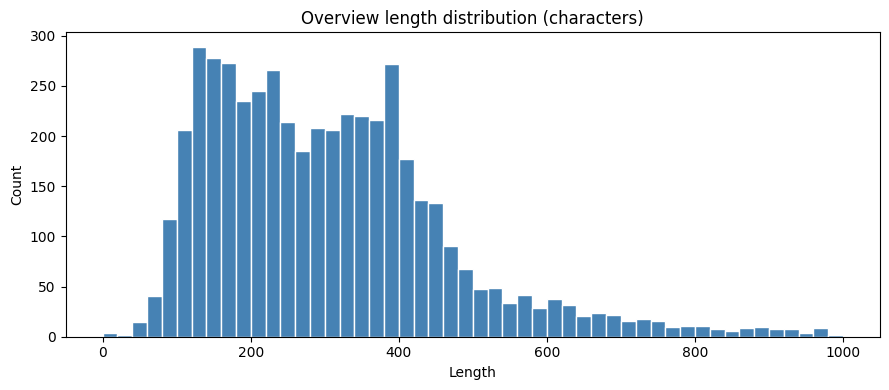

count    4803.000000
mean      305.207995
std       162.886559
min         0.000000
25%       177.500000
50%       283.000000
75%       392.000000
max      1000.000000


In [11]:
# Overview length
movies["overview_len"] = movies["overview"].fillna("").str.len()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(movies["overview_len"], bins=50, color="steelblue", edgecolor="white")
ax.set_title("Overview length distribution (characters)")
ax.set_xlabel("Length")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(movies["overview_len"].describe().to_string())

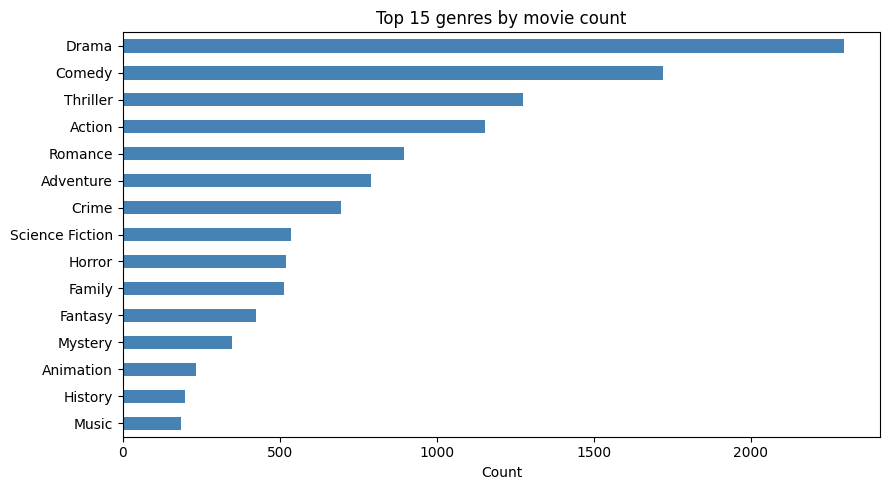

In [12]:
# Movies per genre (top 15)
all_genres = [g["name"] for genres in movies["genres_parsed"] for g in genres]
genre_counts = pd.Series(all_genres).value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
genre_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 genres by movie count")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

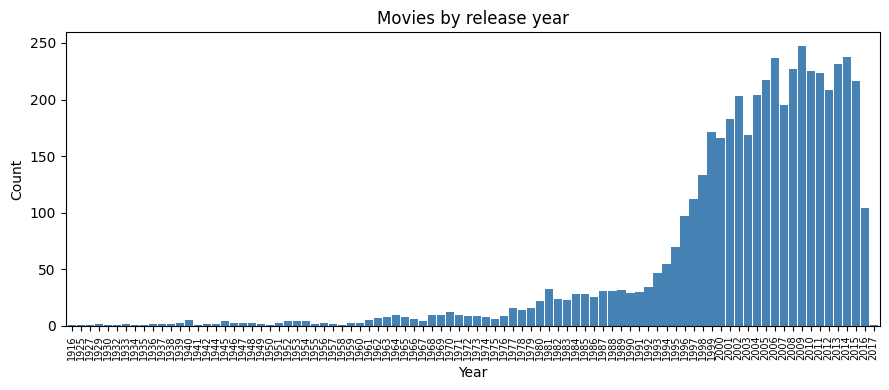

In [13]:
# Release year distribution
movies["release_year"] = pd.to_datetime(movies["release_date"], errors="coerce").dt.year

fig, ax = plt.subplots(figsize=(9, 4))
movies["release_year"].dropna().astype(int).value_counts().sort_index().plot(
    kind="bar", ax=ax, color="steelblue", width=0.9
)
ax.set_title("Movies by release year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()

## 6. Summary

Key findings for the preprocessing pipeline:

- Join key: `movies.id` ↔ `credits.movie_id`
- Parse via `ast.literal_eval`: `genres`, `keywords` (movies), `cast`, `crew` (credits)
- Director: `crew` → filter `job == 'Director'` → take `name`
- Cast: `cast` → sort by `order` → top N `name` values
- Genres: `genres` → `name` values, cap at 5
- `overview` can be null — handle with empty string fallback
- Next: **Step 2** — `cine_rag/data/preprocessing.py`

# EDA — TMDB 5000 Dataset

Exploratory Data Analysis for the two TMDB CSV files before building the preprocessing pipeline.
Goal: understand column structure, missing values, JSON-encoded columns, and the join key.

In [14]:
# Setup
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW_DIR = Path("../raw")
MOVIES_CSV = RAW_DIR / "tmdb_5000_movies.csv"
CREDITS_CSV = RAW_DIR / "tmdb_5000_credits.csv"

print("Files exist:", MOVIES_CSV.exists(), CREDITS_CSV.exists())

Files exist: True True


## 1. Load & basic shape

In [15]:
# Load raw CSVs
movies = pd.read_csv(MOVIES_CSV)
credits = pd.read_csv(CREDITS_CSV)

print("movies shape:", movies.shape)
print("credits shape:", credits.shape)

movies shape: (4803, 20)
credits shape: (4803, 4)


In [16]:
# Column names and dtypes
print("=== movies columns ===")
display(movies.dtypes.to_frame("dtype"))
print("\n=== credits columns ===")
display(credits.dtypes.to_frame("dtype"))

=== movies columns ===


,dtype
budget,int64
genres,str
homepage,str
id,int64
keywords,str
original_language,str
original_title,str
overview,str
popularity,float64
production_companies,str



=== credits columns ===


,dtype
movie_id,int64
title,str
cast,str
crew,str


## 2. Missing values

In [17]:
# Null counts for key columns
key_cols = ["title", "overview", "genres", "release_date", "vote_average"]
display(movies[key_cols].isnull().sum().to_frame("nulls"))

,nulls
title,0
overview,3
genres,0
release_date,1
vote_average,0


In [18]:
# Null counts for credits
display(credits.isnull().sum().to_frame("nulls"))

,nulls
movie_id,0
title,0
cast,0
crew,0


## 3. Join key check

In [19]:
# Verify join key: movies.id <-> credits.movie_id
print("movies.id dtype:", movies["id"].dtype)
print("credits.movie_id dtype:", credits["movie_id"].dtype)

ids_movies = set(movies["id"])
ids_credits = set(credits["movie_id"])

print("movies only:", len(ids_movies - ids_credits))
print("credits only:", len(ids_credits - ids_movies))
print("common:", len(ids_movies & ids_credits))

movies.id dtype: int64
credits.movie_id dtype: int64
movies only: 0
credits only: 0
common: 4803


## 4. JSON-encoded columns

Columns `genres`, `keywords`, `cast`, `crew` are stored as JSON strings — they require `ast.literal_eval` to parse.

In [20]:
# Peek at raw string values
print("genres sample:", movies["genres"].iloc[0])
print("keywords sample:", movies["keywords"].iloc[0])
print("cast sample (credits):", credits["cast"].iloc[0][:120], "...")
print("crew sample (credits):", credits["crew"].iloc[0][:120], "...")

genres sample: [{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]
keywords sample: [{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]
cast sample (credits): [{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685

In [21]:
# Parse and inspect genres
def safe_parse(value: str) -> list:
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

movies["genres_parsed"] = movies["genres"].apply(safe_parse)
genres_sample = movies["genres_parsed"].iloc[0]
print("Parsed genres for first movie:", genres_sample)
print("Genre keys:", list(genres_sample[0].keys()) if genres_sample else "empty")

Parsed genres for first movie: [{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 878, 'name': 'Science Fiction'}]
Genre keys: ['id', 'name']


In [22]:
# Parse cast and crew from credits
credits["cast_parsed"] = credits["cast"].apply(safe_parse)
credits["crew_parsed"] = credits["crew"].apply(safe_parse)

cast_sample = credits["cast_parsed"].iloc[0]
print("Cast keys:", list(cast_sample[0].keys()) if cast_sample else "empty")

crew_sample = credits["crew_parsed"].iloc[0]
print("Crew keys:", list(crew_sample[0].keys()) if crew_sample else "empty")

Cast keys: ['cast_id', 'character', 'credit_id', 'gender', 'id', 'name', 'order']
Crew keys: ['credit_id', 'department', 'gender', 'id', 'job', 'name']


In [23]:
# Director extraction preview
def extract_director(crew: list) -> str:
    for member in crew:
        if member.get("job") == "Director":
            return member.get("name", "")
    return ""

credits["director_preview"] = credits["crew_parsed"].apply(extract_director)
display(credits[["movie_id", "director_preview"]].head(5))

,movie_id,director_preview
0,19995,James Cameron
1,285,Gore Verbinski
2,206647,Sam Mendes
3,49026,Christopher Nolan
4,49529,Andrew Stanton


## 5. Distributions

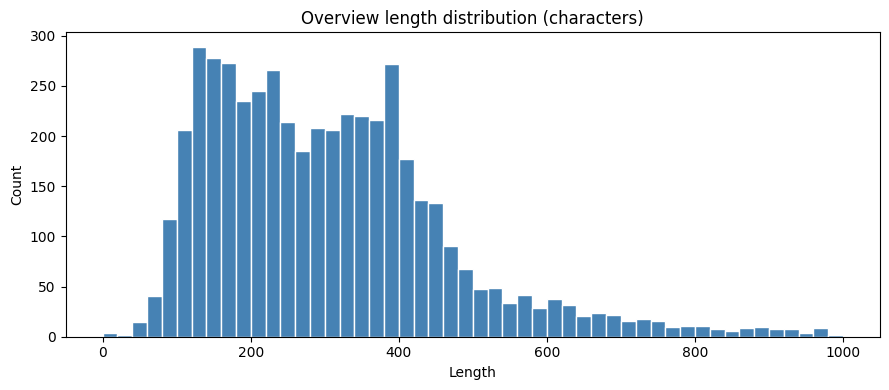

count    4803.000000
mean      305.207995
std       162.886559
min         0.000000
25%       177.500000
50%       283.000000
75%       392.000000
max      1000.000000


In [24]:
# Overview length distribution
movies["overview_len"] = movies["overview"].fillna("").str.len()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(movies["overview_len"], bins=50, color="steelblue", edgecolor="white")
ax.set_title("Overview length distribution (characters)")
ax.set_xlabel("Length")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(movies["overview_len"].describe().to_string())

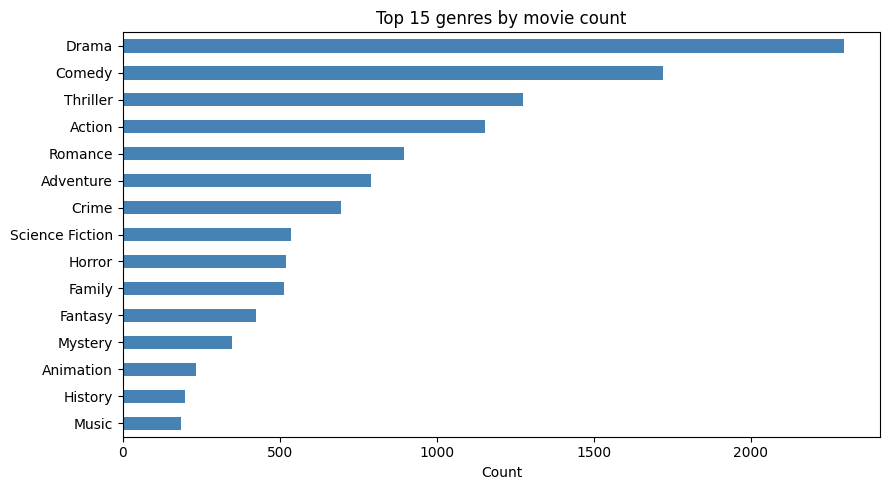

In [25]:
# Movies per genre (top 15)
all_genres = [
    g["name"]
    for genres in movies["genres_parsed"]
    for g in genres
]
genre_counts = pd.Series(all_genres).value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
genre_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 genres by movie count")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

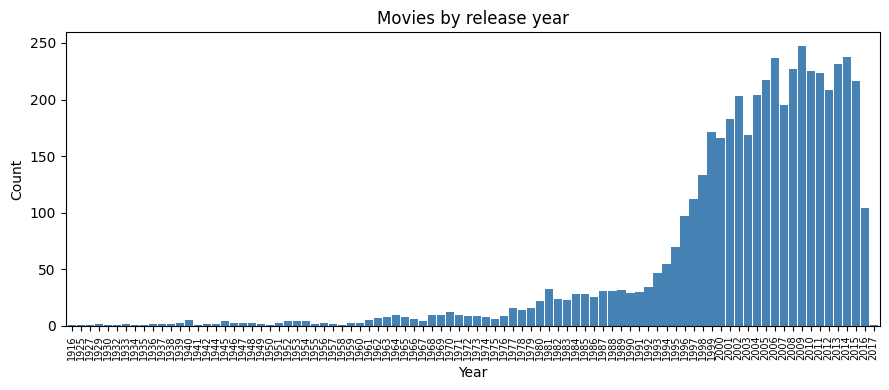

In [26]:
# Release year distribution
movies["release_year"] = pd.to_datetime(movies["release_date"], errors="coerce").dt.year

fig, ax = plt.subplots(figsize=(9, 4))
movies["release_year"].dropna().astype(int).value_counts().sort_index().plot(
    kind="bar", ax=ax, color="steelblue", width=0.9
)
ax.set_title("Movies by release year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()

## 6. Summary

Key findings for the preprocessing pipeline:

- Join key: `movies.id` ↔ `credits.movie_id` (should be full overlap)
- Columns to parse via `ast.literal_eval`: `genres`, `keywords` (movies), `cast`, `crew` (credits)
- Director: `crew` → filter `job == 'Director'` → take `name`
- Cast: `cast` → sort by `order` → take top N `name` values
- Genres: `genres` → take `name` values (cap at 5)
- `overview` can be empty/null — handle with fallback empty string
- Next step: **Step 2** — `cine_rag/data/preprocessing.py`